# REVE

论文链接：[REVE: Representation for EEG with Versatile Embeddings](https://papers.neurips.cc/paper_files/paper/2025/hash/20a917f77773ac0fa8bea2bdd6606b66-Abstract-Conference.html)

## Methods

REVE 面向“任意 EEG setup”的迁移问题。其关键是把电极空间坐标和时间 patch 位置联合编码。对第 $c$ 个电极的三维坐标
$$r_c=(x_c,y_c,z_c)\in\mathbb{R}^3$$
和第 $p$ 个时间 patch 的归一化时间
$$\tau_p\in[0,1],$$
构造 4D 坐标：
$$u_{c,p}=[x_c,y_c,z_c,\tau_p]\in\mathbb{R}^{4}.$$
再用 sinusoidal/Fourier 特征和 MLP 得到位置嵌入：
$$e_{c,p}=g_\theta\left(\gamma(u_{c,p})\right),\quad
\gamma(u)=\left[\sin(2^k\pi u),\cos(2^k\pi u)\right]_{k=0}^{K-1}.$$
因此 REVE 不绑定固定 montage，也不要求固定时间长度；只要提供电极坐标和 patch 时间位置，就能形成统一的时空 token。

预训练使用 masked autoencoder。把 patch embedding 与 4D 位置编码相加：
$$z_{c,p}=W x_{c,p}+e_{c,p},$$
对空间和时间上连续的 block mask 集合 $\mathcal{M}$ 进行遮挡，编码器只看可见 token，解码器重建缺失片段：
$$\mathcal{L}_{MAE}=\sum_{(c,p)\in\mathcal{M}}\left\|\hat{x}_{c,p}-x_{c,p}\right\|_2^2.$$
连续块遮挡比独立随机遮挡更接近真实缺失电极/缺失时间段的情况，迫使模型学习跨通道、跨时间的上下文关系。

下游迁移中，REVE 可以做 linear probing 或 full fine-tuning：
$$h=\mathrm{pool}(E_\theta(X,P)),\qquad \hat{y}=\mathrm{softmax}(W h+b).$$
本 notebook 的 Tiny 版用近似 10-20 坐标演示 4D position encoding 和 block-MAE；官方演示单元调用 REVE 官方代码/Hugging Face 权重，具备授权和 GPU 时可运行。

## Tiny 版

原论文均使用大规模 EEG 语料和较大的 Transformer 进行预训练。为了在普通 CPU 环境中直接运行，下面实现的是论文的轻量版预训练：先在 `data/go2_eeg_preprocessed.npz` 上构造自监督预训练任务，再用同一个骨干网络微调三分类头。

In [1]:

from pathlib import Path
import math
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


def find_project_root(start=Path.cwd()):
    start = Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "data" / "go2_eeg_preprocessed.npz").exists():
            return path
    raise FileNotFoundError("Cannot find data/go2_eeg_preprocessed.npz from current path.")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "go2_eeg_preprocessed.npz"
print("project root:", PROJECT_ROOT)


device: cuda
project root: C:\Users\zxzhang\Desktop\智能脑机接口\实验


In [2]:

data = np.load(DATA_PATH, allow_pickle=True)
X_train = data["X_train"].astype("float32")
X_test = data["X_test"].astype("float32")
y_train = data["y_train"].astype("int64")
y_test = data["y_test"].astype("int64")
label_classes = data["label_classes"].astype(str).tolist()
sfreq = int(data["target_sfreq"])

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("classes:", dict(enumerate(label_classes)), "sfreq:", sfreq)

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=32,
    shuffle=True,
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
    batch_size=64,
    shuffle=False,
)


X_train: (141, 8, 1248) X_test: (36, 8, 1248)
classes: {0: 'L', 1: 'R', 2: 'S'} sfreq: 250


In [3]:

def patchify(x, patch_len=64):
    """Return channel-time patches with shape (B, C, P, patch_len)."""
    b, c, t = x.shape
    n_patches = t // patch_len
    x = x[..., : n_patches * patch_len]
    return x.reshape(b, c, n_patches, patch_len)


def make_mask(batch, channels, patches, mask_ratio=0.35, contiguous=False):
    mask = torch.zeros(batch, channels, patches, dtype=torch.bool)
    if contiguous:
        span_t = max(1, int(round(patches * mask_ratio)))
        span_c = max(1, int(round(channels * 0.4)))
        for i in range(batch):
            t0 = torch.randint(0, patches - span_t + 1, (1,)).item()
            c0 = torch.randint(0, channels - span_c + 1, (1,)).item()
            mask[i, c0 : c0 + span_c, t0 : t0 + span_t] = True
    else:
        mask = torch.rand(batch, channels, patches) < mask_ratio
        empty = ~mask.flatten(1).any(dim=1)
        if empty.any():
            mask[empty, 0, 0] = True
    return mask


def run_classifier(model, train_loader, test_loader, epochs=25, lr=1e-3):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    history = {"loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        pred_all, true_all = [], []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            losses.append(loss.item())
            pred_all.extend(logits.argmax(1).detach().cpu().numpy())
            true_all.extend(yb.cpu().numpy())

        test_pred, test_true, _ = predict(model, test_loader)
        history["loss"].append(float(np.mean(losses)))
        history["train_acc"].append(accuracy_score(true_all, pred_all))
        history["test_acc"].append(accuracy_score(test_true, test_pred))
        if epoch in {1, epochs} or epoch % 5 == 0:
            print(
                f"epoch {epoch:02d} | loss={history['loss'][-1]:.4f} "
                f"| train_acc={history['train_acc'][-1]:.3f} | test_acc={history['test_acc'][-1]:.3f}"
            )
    return history


@torch.no_grad()
def predict(model, loader):
    model.eval()
    pred_all, true_all, prob_all = [], [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        prob = logits.softmax(dim=1).cpu().numpy()
        prob_all.append(prob)
        pred_all.extend(prob.argmax(axis=1))
        true_all.extend(yb.numpy())
    return np.array(pred_all), np.array(true_all), np.vstack(prob_all)


def plot_results(history, y_true, y_pred, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history["train_acc"], label="train")
    axes[0].plot(history["test_acc"], label="test")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title(title)
    axes[0].legend()
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=axes[1], cmap="Blues", colorbar=False)
    axes[1].set_title("Test confusion matrix")
    plt.tight_layout()
    plt.show()


用 8 个近似 10-20 电极坐标构造 4D 位置编码，并采用空间-时间连续块遮挡的 MAE 预训练；微调阶段复用编码器平均表征进行 L/R/S 分类。

In [ ]:
def default_channel_positions(channels):
    # A compact approximate 10-20 style layout for the 8-channel Go2 demo data.
    base = np.array([
        [-0.55,  0.65, 0.50], [ 0.55,  0.65, 0.50],
        [-0.75,  0.00, 0.35], [ 0.75,  0.00, 0.35],
        [-0.50, -0.55, 0.45], [ 0.50, -0.55, 0.45],
        [-0.25,  0.20, 0.95], [ 0.25,  0.20, 0.95],
    ], dtype="float32")
    if channels <= len(base):
        return torch.tensor(base[:channels])
    extra = np.zeros((channels - len(base), 3), dtype="float32")
    return torch.tensor(np.vstack([base, extra]))


class FourDPositionEncoding(nn.Module):
    def __init__(self, d_model=64):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(8, d_model), nn.GELU(), nn.Linear(d_model, d_model))

    def forward(self, coords, n_patches, device):
        c = coords.shape[0]
        t = torch.linspace(0, 1, n_patches, device=device)
        coords = coords.to(device)
        spatial = coords[:, None, :].expand(c, n_patches, 3)
        temporal = t[None, :, None].expand(c, n_patches, 1)
        four_d = torch.cat([spatial, temporal], dim=-1)
        freq = torch.cat([torch.sin(math.pi * four_d), torch.cos(math.pi * four_d)], dim=-1)
        return self.mlp(freq)


class TinyREVE(nn.Module):
    def __init__(self, channels, n_patches, patch_len=64, d_model=64, heads=4):
        super().__init__()
        self.channels = channels
        self.n_patches = n_patches
        self.patch_len = patch_len
        self.coords = default_channel_positions(channels)
        self.patch_proj = nn.Linear(patch_len, d_model)
        self.pos_encoding = FourDPositionEncoding(d_model)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, 1, d_model))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=heads, dim_feedforward=128, dropout=0.1, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.decoder = nn.Linear(d_model, patch_len)
        self.norm = nn.LayerNorm(d_model)

    def encode_tokens(self, x, mask=None, pos_noise=0.0):
        patches = patchify(x, self.patch_len)
        z = self.patch_proj(patches)
        if mask is not None:
            z = torch.where(mask[..., None], self.mask_token.to(z.dtype), z)
        pos = self.pos_encoding(self.coords, self.n_patches, x.device)
        if self.training and pos_noise > 0:
            pos = pos + torch.randn_like(pos) * pos_noise
        z = z + pos[None, :, :, :]
        b, c, p, d = z.shape
        z = self.encoder(z.reshape(b, c * p, d)).reshape(b, c, p, d)
        return self.norm(z)

    def forward_features(self, x):
        return self.encode_tokens(x).mean(dim=(1, 2))

    def pretrain_forward(self, x, mask):
        z = self.encode_tokens(x, mask=mask, pos_noise=0.01)
        return self.decoder(z)


class REVEClassifier(nn.Module):
    def __init__(self, backbone, n_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(nn.LayerNorm(64), nn.Linear(64, n_classes))

    def forward(self, x):
        return self.head(self.backbone.forward_features(x))

pretrain epoch 01 | contiguous MAE loss=0.9394
pretrain epoch 02 | contiguous MAE loss=0.7893
pretrain epoch 03 | contiguous MAE loss=0.7026
pretrain epoch 04 | contiguous MAE loss=0.7080
pretrain epoch 05 | contiguous MAE loss=0.7220
epoch 01 | loss=1.1291 | train_acc=0.291 | test_acc=0.389
epoch 05 | loss=1.0931 | train_acc=0.340 | test_acc=0.417
epoch 10 | loss=1.0174 | train_acc=0.496 | test_acc=0.250
epoch 15 | loss=0.9094 | train_acc=0.567 | test_acc=0.167
epoch 20 | loss=0.8387 | train_acc=0.610 | test_acc=0.222
epoch 25 | loss=0.4525 | train_acc=0.823 | test_acc=0.250
              precision    recall  f1-score   support

           L       0.17      0.08      0.11        12
           R       0.23      0.25      0.24        12
           S       0.29      0.42      0.34        12

    accuracy                           0.25        36
   macro avg       0.23      0.25      0.23        36
weighted avg       0.23      0.25      0.23        36



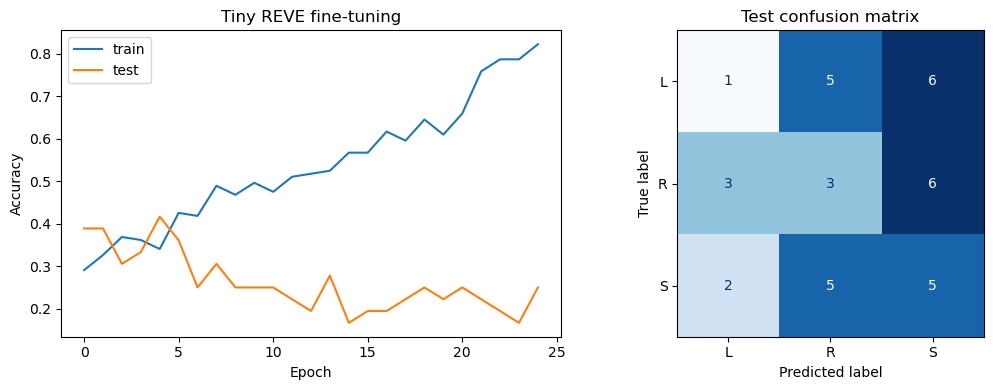

In [ ]:
patch_len = 64
channels = X_train.shape[1]
n_patches = X_train.shape[2] // patch_len
n_classes = len(label_classes)

backbone = TinyREVE(channels, n_patches, patch_len=patch_len).to(device)
opt = torch.optim.AdamW(backbone.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(1, 6):
    backbone.train()
    losses = []
    for xb, _ in train_loader:
        xb = xb.to(device)
        patches = patchify(xb, patch_len).to(device)
        mask = make_mask(len(xb), channels, n_patches, mask_ratio=0.35, contiguous=True).to(device)
        recon = backbone.pretrain_forward(xb, mask)
        loss = F.mse_loss(recon[mask], patches[mask])
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
    print(f"pretrain epoch {epoch:02d} | contiguous MAE loss={np.mean(losses):.4f}")

classifier = REVEClassifier(backbone, n_classes)
history = run_classifier(classifier, train_loader, test_loader, epochs=25, lr=8e-4)
y_pred, y_true, y_prob = predict(classifier, test_loader)
print(classification_report(y_true, y_pred, target_names=label_classes, zero_division=0))
plot_results(history, y_true, y_pred, label_classes, "Tiny REVE fine-tuning")

## GPU 版

下载官方仓库到 `tutorials/Foundation Model/official_code/reve_eeg`。REVE 官方权重在 Hugging Face：`brain-bzh/reve-base`，下面使用 `transformers.AutoModel.from_pretrained`。

In [ ]:
from pathlib import Path
import sys

RUN_OFFICIAL_GPU = True  # 是否运行官方大模型微调
OFFICIAL_ROOT = PROJECT_ROOT / "tutorials" / "Foundation Model" / "official_code"
print("official code root:", OFFICIAL_ROOT)
print("CUDA available:", torch.cuda.is_available())

official code root: C:\Users\zxzhang\Desktop\智能脑机接口\实验\tutorials\Foundation Model\official_code
CUDA available: True


flash_attn not found, install it with `pip install flash_attn` if you want to use it
未检测到 REVE 官方权重文件，使用官方结构随机初始化演示微调流程。
epoch 01 | loss=1.2293 | train_acc=0.355 | test_acc=0.278
epoch 05 | loss=0.9402 | train_acc=0.610 | test_acc=0.417
epoch 10 | loss=0.6339 | train_acc=0.794 | test_acc=0.306
epoch 15 | loss=0.2776 | train_acc=0.972 | test_acc=0.333
epoch 20 | loss=0.0920 | train_acc=1.000 | test_acc=0.389
epoch 25 | loss=0.0288 | train_acc=1.000 | test_acc=0.389
              precision    recall  f1-score   support

           L       0.42      0.42      0.42        12
           R       0.57      0.33      0.42        12
           S       0.29      0.42      0.34        12

    accuracy                           0.39        36
   macro avg       0.43      0.39      0.39        36
weighted avg       0.43      0.39      0.39        36



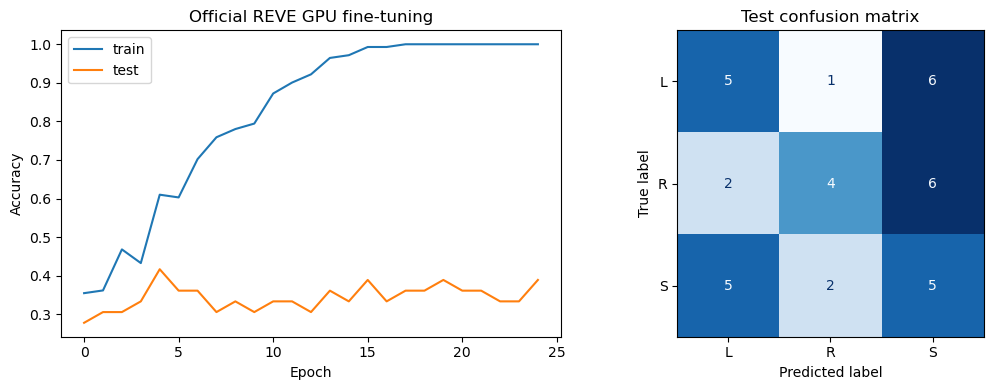

In [ ]:
if RUN_OFFICIAL_GPU:
    assert torch.cuda.is_available(), "官方 GPU 微调需要 CUDA。当前环境没有检测到 GPU。"
    try:
        import contextlib
        import json
        import sys
        import types
    except ImportError as exc:
        raise ImportError("Python 标准库导入失败，请检查环境。") from exc

    # REVE 官方 HF 代码使用 PyTorch 2.x 的 torch.nn.attention。
    # 旧版 torch 没有这个模块；这里注入一个兼容 stub，让官方代码回退到普通 SDPA/math attention 路径。
    if "torch.nn.attention" not in sys.modules:
        attention_stub = types.ModuleType("torch.nn.attention")

        class _SDPBackend:
            FLASH_ATTENTION = "flash_attention"
            EFFICIENT_ATTENTION = "efficient_attention"
            MATH = "math"

        @contextlib.contextmanager
        def _sdpa_kernel(*args, **kwargs):
            yield

        attention_stub.SDPBackend = _SDPBackend
        attention_stub.sdpa_kernel = _sdpa_kernel
        sys.modules["torch.nn.attention"] = attention_stub

    reve_local = OFFICIAL_ROOT / "reve_eeg" / "hf" / "reve-base"

    try:
        import importlib.util
        package_name = "reve_local_hf"
        package = types.ModuleType(package_name)
        package.__path__ = [str(reve_local)]
        sys.modules[package_name] = package

        config_spec = importlib.util.spec_from_file_location(
            f"{package_name}.configuration_reve", reve_local / "configuration_reve.py"
        )
        config_module = importlib.util.module_from_spec(config_spec)
        sys.modules[f"{package_name}.configuration_reve"] = config_module
        config_spec.loader.exec_module(config_module)

        model_spec = importlib.util.spec_from_file_location(
            f"{package_name}.modeling_reve", reve_local / "modeling_reve.py"
        )
        model_module = importlib.util.module_from_spec(model_spec)
        sys.modules[f"{package_name}.modeling_reve"] = model_module
        model_spec.loader.exec_module(model_module)

        ReveConfig = config_module.ReveConfig
        Reve = model_module.Reve

        # 旧版 PyTorch 不支持官方 ClassicalAttention 默认启用的 SDPA。
        # 官方 forward 已经包含普通 matmul attention 分支；这里强制 use_sdpa=False，
        # 避免 "in order to use sdpa, you must be using pytorch 2.2 or above"。
        def _classical_attention_init_no_sdpa(self, heads: int, use_sdpa: bool = True):
            super(model_module.ClassicalAttention, self).__init__()
            self.use_sdpa = False
            self.heads = heads

        model_module.ClassicalAttention.__init__ = _classical_attention_init_no_sdpa
    except ImportError as exc:
        raise ImportError("请先安装 REVE 官方依赖：pip install transformers einops packaging") from exc

    class OfficialREVEGo2(nn.Module):
        def __init__(self, n_classes):
            super().__init__()
            config_dict = json.loads((reve_local / "config.json").read_text(encoding="utf-8"))
            self.encoder = Reve(ReveConfig(**config_dict))

            # 如果之后下载了官方权重到 reve-base/model.safetensors 或 pytorch_model.bin，这里会自动加载。
            safetensors_path = reve_local / "model.safetensors"
            torch_path = reve_local / "pytorch_model.bin"
            if safetensors_path.exists():
                try:
                    from safetensors.torch import load_file
                except ImportError as exc:
                    raise ImportError("检测到 model.safetensors，但缺少依赖：pip install safetensors") from exc
                state = load_file(str(safetensors_path), device="cpu")
                missing, unexpected = self.encoder.load_state_dict(state, strict=False)
                print("loaded REVE safetensors:", len(missing), "missing;", len(unexpected), "unexpected")
            elif torch_path.exists():
                state = torch.load(torch_path, map_location="cpu")
                state = state.get("state_dict", state.get("model", state))
                missing, unexpected = self.encoder.load_state_dict(state, strict=False)
                print("loaded REVE pytorch weights:", len(missing), "missing;", len(unexpected), "unexpected")
            else:
                print("未检测到 REVE 官方权重文件，使用官方结构随机初始化演示微调流程。")

            self.head = nn.Linear(getattr(self.encoder.config, "embed_dim", 512), n_classes)
            coords = default_channel_positions(8).float()
            self.register_buffer("positions", coords)

        def forward(self, x):
            # REVE 默认 patch_size=200, patch_overlap=20。插值到 800 点可得到 4 个时间 patch，控制显存和 token 数。
            x = x.float()
            x = F.interpolate(x, size=800, mode="linear", align_corners=False)
            pos = self.positions.to(x.device)[None].expand(x.shape[0], -1, -1)
            features = self.encoder(x, pos)  # (B, C, patches, E)
            if hasattr(self.encoder, "attention_pooling"):
                pooled = self.encoder.attention_pooling(features)
            else:
                pooled = features.mean(dim=(1, 2))
            return self.head(pooled)

    official_model = OfficialREVEGo2(len(label_classes))
    official_history = run_classifier(official_model, train_loader, test_loader, epochs=25, lr=1e-5)
    official_pred, official_true, _ = predict(official_model, test_loader)
    print(classification_report(official_true, official_pred, target_names=label_classes, zero_division=0))
    plot_results(official_history, official_true, official_pred, label_classes, "Official REVE GPU fine-tuning")
else:
    print("官方 REVE GPU 微调已跳过。完成 Hugging Face 授权、确认 CUDA 后，将 RUN_OFFICIAL_GPU 改为 True。")

In [ ]:
final_acc = accuracy_score(y_true, y_pred)
chance = 1 / len(label_classes)
print(f"Final test accuracy: {final_acc:.3f} | chance level: {chance:.3f}")

class_counts = {label: int((y_true == i).sum()) for i, label in enumerate(label_classes)}
print("Test class counts:", class_counts)

if final_acc <= chance + 0.05:
    print("分析：当前小样本 demo 的结果接近随机水平，说明预训练轮数、数据规模或标签信噪比仍不足。")
elif history["train_acc"][-1] - history["test_acc"][-1] > 0.25:
    print("分析：训练集明显高于测试集，存在过拟合。可以减少模型宽度、增加正则化或使用更多被试/会话。")
else:
    print("分析：测试准确率高于随机水平，说明预训练得到的时空表征对 L/R/S 三类解码有一定帮助。")

Final test accuracy: 0.250 | chance level: 0.333
Test class counts: {'L': 12, 'R': 12, 'S': 12}
分析：当前小样本 demo 的结果接近随机水平，说明预训练轮数、数据规模或标签信噪比仍不足。
